# Imports

In [158]:
import numpy as np
import scipy
import math
import random

import matplotlib.pyplot as plt

from numba import njit

import networkx as nx

# Ising formulations of many NP problems
Importing the code _spinglass.ipynb_ from 

In [56]:
def energy(s, J, h):
    # s is a flat 1D array of spins
    # J is (n, n) matrix
    # h is (n) vector
    return 0.5 * s @ J @ s - h @ s

@njit
def sweep_once(s, J, h, T, E):
    n=len(s)
    for _ in range(n):
        i = np.random.randint(n)
        
        dE = 2 * s[i] * (J[i] @s + h[i])        

        if dE <= 0 or np.random.rand() < math.exp(-dE / T):
            s[i] *= -1
            E += dE

    return E

def sim_annealing(J, h, T_start, T_end, alpha, sweeps_per_T):
    n = J.shape[0]
    s = np.random.choice(np.array([-1, 1]), size=n).astype(np.float64)

    E = energy(s, J, h)
    
    temps = []
    energies = []
    
    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once(s, J, h, T, E)
        
        temps.append(T)
        energies.append(E)
        T *= alpha
    
    return np.array(temps), np.array(energies), s.copy()


# Partitioning Problems
These partitioning problems are based off _spinglass.ipynb_  where we have a spin glass model.

$H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$.

 We will need to swap the general ising model build function `make_2d_ising(N,J_scalar,h_scalar)` to a function that has our problems ising structure. Building Q based off the energy cost function is our goal here.

## Number Partitioning 
Given a set of $N$ positive numbers $S=\{n_1,\cdots ,n_N\}$, is there a partition of numbers into two disjoint sets such that $R$ and $S-R$ have equal sums of their elements?

Our cost function will be,

$H=-A\left(\sum_i^Nn_is_i\right)^2=$

$\underbrace{-A\sum_{i=j}^Nn_i^2}_\text{constant}-2A\sum_{i<j}^Nn_in_js_is_j$

we can drop the constant in our optimization.

In our spin glass form $H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$.

$J_{ij}=-An_in_j$

$h_i=0$

In [57]:
def make_partition_ising_slower(n,A=1.0):
    n = np.asarray(n, dtype=np.float64)
    N=len(n)
    J = np.zeros((N,N))
    
    for i in range(N):
        for j in range(i+1,N):
            J[i,j] = -A * n[i] * n[j]
            J[j,i] = J[i,j]
    
    h = np.zeros(N)
    
    return J, h
    
def make_partition_ising(n, A=1.0):
    n = np.asarray(n, dtype=np.float64)

    J = -2 * A * np.outer(n, n)
    np.fill_diagonal(J, 0.0)

    h = np.zeros(len(n))

    return J, h

This structure defines ouf Q interaction matrix.

In [58]:
numbers = np.array([3,1,1,2,2,1])

J, h = make_partition_ising(numbers)

temps, energies, spins = sim_annealing(
    J, h,
    T_start=10,
    T_end=0.01,
    alpha=0.99,
    sweeps_per_T=100
)

setA = numbers[spins == 1]
setB = numbers[spins == -1]

print("Set A:", setA, "sum =", np.sum(setA))
print("Set B:", setB, "sum =", np.sum(setB))
print("Difference =", abs(np.sum(setA) - np.sum(setB)))

Set A: [3 2] sum = 5
Set B: [1 1 2 1] sum = 5
Difference = 0


Defining a function for this problem

In [59]:
def run_partition_example(numbers,sweeps):
    print("Inputed numbers:", numbers)

    J, h = make_partition_ising(numbers)

    temps, energies, spins = sim_annealing(
        J, h,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=sweeps
    )

    setA = numbers[spins == 1]
    setB = numbers[spins == -1]

    print("Set A:", setA, "sum =", np.sum(setA))
    print("Set B:", setB, "sum =", np.sum(setB))
    print("Difference =", abs(np.sum(setA) - np.sum(setB)))

We can try it for a random $n_i=rand$ for $S=\{n_1,\cdots ,n_N\}$

In [60]:
for _ in range(5):
    random_numbers = np.random.randint(1, 100, size=20)
    print(run_partition_example(random_numbers, 1000))

Inputed numbers: [95 85 64 18 70 37 41 45 89 51 39 64 16 22 68 51  1 61 95 78]
Set A: [95 85 18 89 39 64 61 95] sum = 546
Set B: [64 70 37 41 45 51 16 22 68 51  1 78] sum = 544
Difference = 2
None
Inputed numbers: [15 77 39  4 48 85 24 64 29 82 99 74 91 79 17 16 25 85 89 67]
Set A: [15 77 39 24 64 79 17 85 89 67] sum = 556
Set B: [ 4 48 85 29 82 99 74 91 16 25] sum = 553
Difference = 3
None
Inputed numbers: [19 48 20 66 39 63 97 65 72 34  9 81 76 17 72  5 78 55 91 55]
Set A: [48 20 66 39 63 72  9 81 78 55] sum = 531
Set B: [19 97 65 34 76 17 72  5 91 55] sum = 531
Difference = 0
None
Inputed numbers: [44 54 22 81 33 35 68 24 76 55 36  3 79 62 25 49 27 35 23 66]
Set A: [22 68 76 55  3 62 27 35 23 66] sum = 437
Set B: [44 54 81 33 35 24 36 79 25 49] sum = 460
Difference = 23
None
Inputed numbers: [72 63 87 98 21 97 19 69 92 45 62 54 49 76 97 94 54 54 31 37]
Set A: [63 87 98 21 92 62 49 97 31 37] sum = 637
Set B: [72 97 19 69 45 54 76 94 54 54] sum = 634
Difference = 3
None


It solves our problem to the best of its ability, minimising the distance between two sets.

## Graph Partitioning

Given some undirected graph $G(V,E)$, where $v\in v$ are vertices and $e\in E$ are edges, we take a graph with and even number of edges $N=|V|$. The optimisation problem, what is the partition of V into two subsets that minimises the number of edges connecting the two subsets?

$ H=H_A+H_B$

$=A\left(\sum_i^Ns_i\right)^2+B\sum_{(i,j)\in E}\frac{1-s_is_j}{2}$

$=\underbrace{AN} _{\text{constant}}+\underbrace{\frac{B|E|}{2}}_{\text{constant}}+2A\sum_{i>j}^ Ns_is_j -\frac{B}{2}\sum_{(i,j)\in E}  s_is_j$

In our spin glass form $H=-\sum_{\langle ij\rangle}J_{ij}s_is_j-\sum_jh_js_j$. 

$J_{ij}=\begin{cases}
        -2A ~~~~~~~~~\text{if }~(i,j)\notin E\\
        -2A -\frac{B}{2}~~~\text{if }~(i,j)\in E
    \end{cases}$

$h_i=0$

In [159]:
nodes = ['a', 'b', 'c', 'd']
#     idx 0    1    2    3
idx = {v: i for i, v in enumerate(nodes)}

print(nodes)
print(idx)

# idx swaps label and index of nodes in a graph

['a', 'b', 'c', 'd']
{'a': 0, 'b': 1, 'c': 2, 'd': 3}


In [160]:
def make_graph_partition(G, A, B):
    N = G.number_of_nodes()
    nodes = list(G.nodes())
    
    J = -2.0 * A * np.ones((N, N))
    np.fill_diagonal(J, 0.0)
    
    #
    idx = {v:i for i,v in enumerate(nodes)}
    
    for u,v in G.edges():
        i, j = idx[u], idx[v]
        J[i,j] += B/2.0
        J[j,i] += B/2.0
    
    h = np.zeros(N)
    return J, h

def decode_partition_solution(G, s):
    nodes = list(G.nodes())
    
    setA = [nodes[i] for i in range(len(s)) if s[i] == 1]
    setB = [nodes[i] for i in range(len(s)) if s[i] == -1]
    
    cut_edges = [(u,v) for u,v in G.edges() if (u in setA) != (v in setA)]
    
    print ("Set A:", setA , "size =", len(setA))
    print ("Set B:", setB , "size =", len(setB))
    print ("Cut edges:", cut_edges , "size =", len(cut_edges))
    
    return setA, setB, cut_edges

def check_valid_AB(A,B,G):
    N=G.number_of_nodes()
    delta=max(d for _,d in G.degree()) # max degree of graph
    rhs=min(2*delta, N)/8 
    lhs= A / B
    valid = lhs >= rhs
    print(f"Max degree Δ={delta},  bound A/|B| >= {rhs:.3f}")
    print(f"Current A/|B| = {lhs:.3f}  {'valid' if valid else 'INVALID'}")
    
    return valid

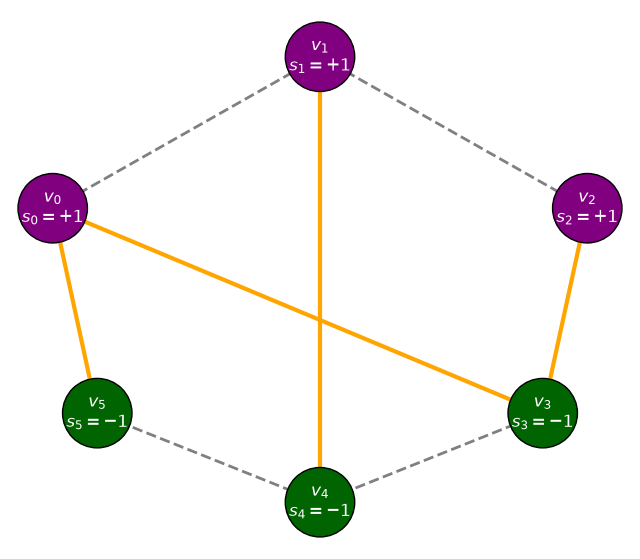

In [161]:
# Cycle graph C6 plus two connections
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

# positions for nodes in the graph for plotting to match my layout in Tikz
pos = {
    0: (0, 1.5),
    1: (3, 3.2),
    2: (6, 1.5),
    3: (5.5, -0.8),
    4: (3, -1.8),
    5: (0.5, -0.8)
}

# worst spin configuration
spins = np.array([1, 1, 1, -1, -1, -1])

# Colour nodes
node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

# Separate cut and internal edges
cut_edges = []
internal_edges = []

for u, v in G.edges():
    if spins[u] != spins[v]:
        cut_edges.append((u, v))
    else:
        internal_edges.append((u, v))

plt.figure(figsize=(8,7))

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=2500,
    edgecolors='black'
)

# Labels
labels = {i: f"$v_{i}$\n$s_{{{i}}}={spins[i]:+d}$" for i in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_color='white')

# Internal edges 
nx.draw_networkx_edges(
    G, pos,
    edgelist=internal_edges,
    edge_color='gray',
    style='dashed',
    width=2
)

# Cut edges 
nx.draw_networkx_edges(
    G, pos,
    edgelist=cut_edges,
    edge_color='orange',
    width=3
)

plt.axis('off')
plt.axis('equal')
plt.show()

We can make a plotting function without defining postions using `pos = nx.spring_layout(G, seed=13)` with a seed for reproducibility. Instead of inputing

`pos = {
    0: (0, 1.5),
    1: (3, 3.2),
    2: (6, 1.5),
    3: (5.5, -0.8),
    4: (3, -1.8),
    5: (0.5, -0.8)
}`

We'll also make a spin-less/empty node graph function

In [ ]:
def draw_empty_graph(G):
    pos = nx.spring_layout(G, seed=13)  

    n = G.number_of_nodes()
    
    node_colors = 'purple'

    all_edges = []

    for u, v in G.edges():
        all_edges.append((u, v))

    size = max(9, 0.8 * n)
    plt.figure(figsize = (size, size))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=2500,
        edgecolors='black'
    )

    # Labels
    labels = {i: f"$v_{i}$" for i in G.nodes}
    nx.draw_networkx_labels(G, pos, labels, font_color='white')

    # Internal edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=all_edges,
        edge_color='gray',
        style='dashed',
        width=2
    )

    plt.axis('off')
    plt.axis('equal')
    plt.show()

And one with the cut edges defined once we input a spin.

In [182]:
def draw_graph_partition(G, spins):
    pos = nx.spring_layout(G, seed=13)  
    
    # Colour nodes
    node_colors = ['purple' if s == 1 else 'darkgreen' for s in spins]

    # Separate cut and internal edges
    cut_edges = []
    internal_edges = []

    for u, v in G.edges():
        if spins[u] != spins[v]:
            cut_edges.append((u, v))
        else:
            internal_edges.append((u, v))

    n = G.number_of_nodes()
    
    size = max(9, 0.8 * n)
    plt.figure(figsize = (size, size))

    # Nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=2500,
        edgecolors='black'
    )

    # Labels
    #labels = {i: f"$v_{i}$\n${spins[i]}$" for i in G.nodes}
    labels = {}

    for i in G.nodes:
        arrow = r"\uparrow" if spins[i] == 1 else r"\downarrow"
        labels[i] = f"$v_{{i}}$\n$s_{{{i}}}={arrow}$"
    
    nx.draw_networkx_labels(G, pos, labels, font_color='white')

    # Internal edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=internal_edges,
        edge_color='gray',
        style='dashed',
        width=2
    )

    # Cut edges 
    nx.draw_networkx_edges(
        G, pos,
        edgelist=cut_edges,
        edge_color='orange',
        width=3
    )

    plt.axis('off')
    plt.axis('equal')
    plt.show()

In [164]:
def run_partition_graph_example(G, A, B, sweeps):
    print("Inputed graph:")
    draw_empty_graph(G)
    
    print(f"A={A}, B={B}")
    check_valid_AB(A, B, G)

    J, h = make_graph_partition(G, A, B)

    temps, energies, spins = sim_annealing(
        J, h,
        T_start=10,
        T_end=0.01,
        alpha=0.99,
        sweeps_per_T=sweeps
    )

    #setA, setB, cut_edges = decode_partition_solution(G, spins)
    
    draw_graph_partition(G, spins)

Inputed graph:


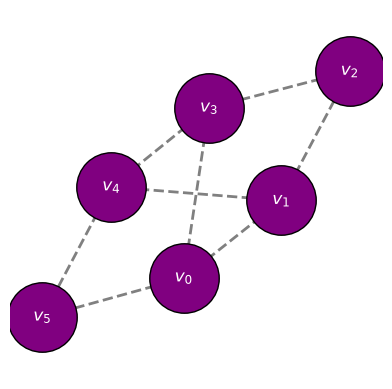

A=4, B=2
Max degree Δ=3,  bound A/|B| >= 0.750
Current A/|B| = 2.000  valid


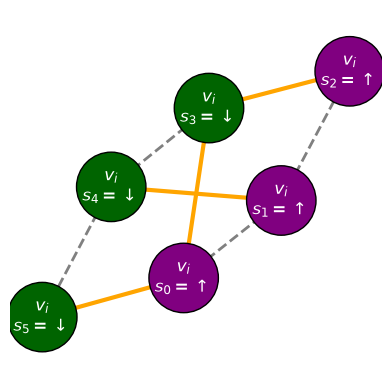

In [165]:
G = nx.cycle_graph(6)
G.add_edge(0, 3)
G.add_edge(1, 4)

run_partition_graph_example(G, A=4, B=2, sweeps=1000)

That is solving the problem to minimise the cut edes, now we can try it with random $G(E,V)$

In [166]:
def run_random_partition_graph_example(lower, upper):
    # Random even number of vertices between 6 and 14
    n = random.choice(range(lower, upper, 2))

    # Create the cycle graph C_n
    G = nx.cycle_graph(n)

    # Number of extra edges to add
    num_extra = random.randint(2, n // 2) # divides by two and rounds down

    added = 0
    while added < num_extra:
        u, v = random.sample(range(n), 2)

        # Skip if edge already exists
        if G.has_edge(u, v):
            continue

        G.add_edge(u, v)
        added += 1

    print(f"n = {n}")
    print(f"Added {num_extra} extra edges")

    run_partition_graph_example(G, A=4, B=2, sweeps=1000)

n = 6
Added 3 extra edges
Inputed graph:


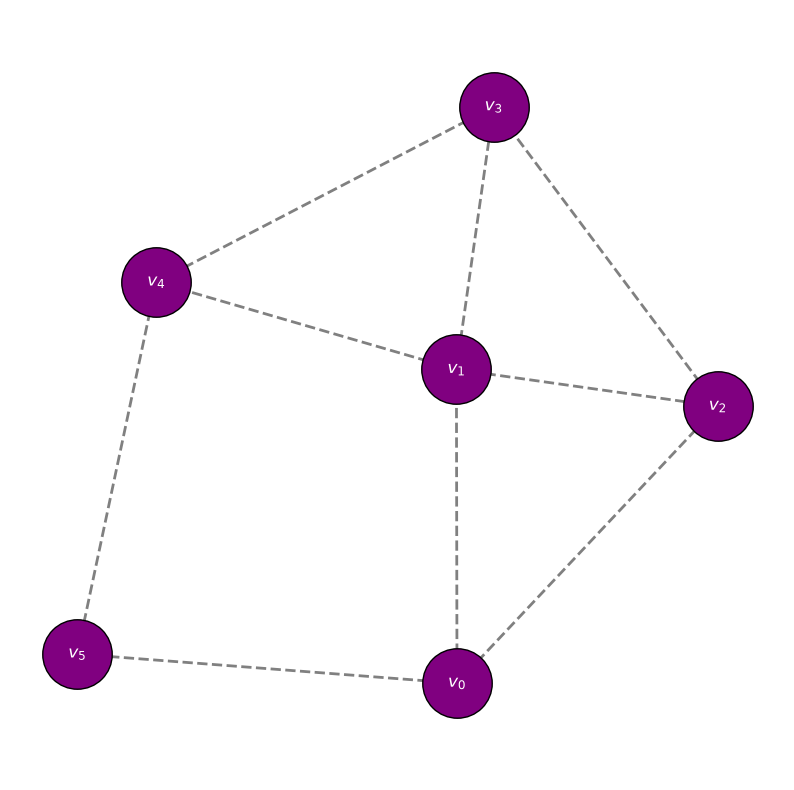

A=4, B=2
Max degree Δ=4,  bound A/|B| >= 0.750
Current A/|B| = 2.000  valid


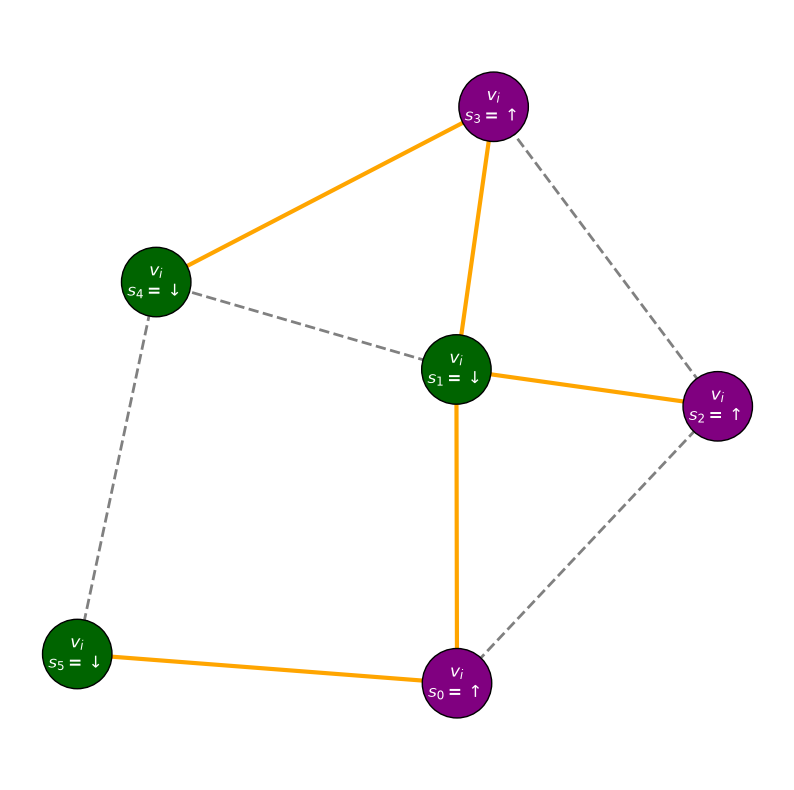

In [181]:
run_random_partition_graph_example(6, 8)